# M04. Pulls
- This predicts when starting pitchers are removed from a game
- Type: Model
- Run Frequency: Irregular
- Sources:
    - MLB Stats API
    - Steamer
- Created: 11/1/2023
- Updated: 5/3/2026

### Imports

In [1]:
from U01Imports import *
from U02Functions import *
from U03Classes import *
from U04Datasets import *
from U05Models import *

Using device: cuda


### Settings

In [2]:
min_training_date, max_training_date = '2021-01-01', '2026-06-30'
min_testing_date, max_testing_date = '2025-01-01', '2026-06-30'

### Data

##### Plate Appearances

In [3]:
complete_dataset = pd.read_csv(os.path.join(baseball_path, "PA Dataset.csv"))

##### Steamer

In [4]:
steamer_pitchers_df = pd.read_csv(os.path.join(baseball_path, "A03. Steamer", "Pitchers", "Steamer Pitchers Dataset.csv"), encoding='iso-8859-1')

### Clean

##### Plate Appearances

In the model, pulls occur before the PA, not after, so innings and outs need to be adjusted

In [5]:
complete_dataset['inning_adj'] = complete_dataset['inning'] + (complete_dataset['outs'] == 3).astype(int)
complete_dataset['outs_adj'] = complete_dataset['outs'] * (complete_dataset['outs'] != 3).astype(int)

To account for the inning shift, inning stat sums should be reset

In [6]:
for variable in events_list + ['faced', 'reached', 'outs_pa']:
    complete_dataset[f'{variable}_inning_adj'] = np.where(complete_dataset['outs'] == 3, 0, complete_dataset[f'{variable}_inning'])
    complete_dataset[f'{variable}_game_adj'] = complete_dataset[f'{variable}_game'].copy()

To match the model, imputation flags should be determined at the beginning of the game 

In [7]:
complete_dataset['imp_p_adj'] = complete_dataset.groupby(['gamePk', 'pitcher'])['imp_p'].transform('max')

Format dates

In [8]:
complete_dataset['date_time'] = pd.to_datetime(complete_dataset['date'], format='%Y%m%d')
complete_dataset['pitcher'] =complete_dataset['pitcher'].astype(int).astype(str)

##### Steamer

Standardize and drop missings

In [9]:
steamer_pitchers_df2 = clean_steamer_pitchers(steamer_pitchers_df)
steamer_pitchers_df2.dropna(subset=['IP_start'], inplace=True)

In [10]:
steamer_pitchers_df2 = steamer_pitchers_df2[~steamer_pitchers_df2['mlbamid'].isna()]

Format for merge

In [11]:
steamer_pitchers_df2['date_time'] = pd.to_datetime(steamer_pitchers_df2['date'], format='%Y%m%d')
steamer_pitchers_df2['pitcher'] = steamer_pitchers_df2['mlbamid'].astype(int).astype(str)

### Merge

Merge asof most recent date in Steamer

In [12]:
complete_merged_df = pd.merge_asof(
    complete_dataset,
    steamer_pitchers_df2,
    on='date_time',
    by='pitcher',
    suffixes=('', '_fg'),
    direction='backward'
)

### Sample

Only keep one observation per at bat

In [13]:
complete_merged_df.drop_duplicates(subset=['date', 'gamePk', 'atBatIndex'], keep='last', inplace=True)

Keep those with reasonable IP/start projections 

In [14]:
complete_merged_df = complete_merged_df.query('IP_start > 3 and IP_start < 8')

Only keep starting pitchers

In [15]:
complete_merged_df = complete_merged_df[complete_merged_df['starter'] == 1]

Drop early observations (insufficient sample size) and recent observations (no Steamer data)

In [16]:
# Keep observations within the overall train+test span; masks below split them.
complete_merged_df = complete_merged_df[
    (complete_merged_df['game_date'] >= min_training_date)
    & (complete_merged_df['game_date'] <= max_testing_date)
]

### Model

$ \hat{\text{pulled}} = cumulative\_inning\_list (subset) +  cumulative\_game\_list (subset) + inning\_dummy\_list + out\_dummy\_list + game\_state\_list + IP\_start + imp\_p\_adj$

##### Inputs

Inning dummies

In [17]:
for inning in range(1, 12):
    complete_merged_df[f'inning_{inning}'] = (complete_merged_df['inning_adj'] == inning).astype(int)
complete_merged_df['inning_11'] = (complete_merged_df['inning_adj'] >= 11).astype(int)

In [18]:
inning_dummy_list = [col for col in complete_merged_df.columns if col.startswith("inning_")]
inning_dummy_list.remove('inning_adj')

Out dummies

In [19]:
for out in range(0, 3):
    complete_merged_df[f'outs_{out}'] = (complete_merged_df['outs_adj'] == out).astype(int)

In [20]:
out_dummy_list = ['outs_0', 'outs_1', 'outs_2']

Cumulative variables

In [21]:
cumulative_inning_list = [col for col in complete_merged_df.columns if col.endswith("_inning_adj")]

Exclude outs recorded by the pitcher that inning (redudant with inning dummies for starting pitchers)

In [22]:
cumulative_inning_list.remove('outs_pa_inning_adj')

In [23]:
cumulative_game_list = [col for col in complete_merged_df.columns if col.endswith("_game_adj")]

Game state variables

In [24]:
game_state_list = ['pitcherScore', 'batterScore', 'onFirst', 'onSecond', 'onThird']

Steamer variables

In [25]:
steamer_list = ['IP_start']

Imputation dummy

In [26]:
imp_list = ['imp_p_adj']

Model Inputs

In [27]:
pull_inputs = ['faced_inning_adj', 'reached_inning_adj'] + ['faced_game_adj', 'reached_game_adj', 'outs_pa_game_adj'] + inning_dummy_list + out_dummy_list + game_state_list + steamer_list + imp_list

In [28]:
pull_inputs

['faced_inning_adj',
 'reached_inning_adj',
 'faced_game_adj',
 'reached_game_adj',
 'outs_pa_game_adj',
 'inning_1',
 'inning_2',
 'inning_3',
 'inning_4',
 'inning_5',
 'inning_6',
 'inning_7',
 'inning_8',
 'inning_9',
 'inning_10',
 'inning_11',
 'outs_0',
 'outs_1',
 'outs_2',
 'pitcherScore',
 'batterScore',
 'onFirst',
 'onSecond',
 'onThird',
 'IP_start',
 'imp_p_adj']

##### Train/Test Split

Split into training and testing sets by date window (`min/max_training_date`, `min/max_testing_date`).

In [29]:
train_mask = complete_merged_df['game_date'].between(min_training_date, max_training_date)
test_mask  = complete_merged_df['game_date'].between(min_testing_date,  max_testing_date)

training_dataset = complete_merged_df[train_mask].reset_index(drop=True)
testing_dataset  = complete_merged_df[test_mask].reset_index(drop=True)

print(f"Train rows: {len(training_dataset):,} ({min_training_date} to {max_training_date})")
print(f"Test rows:  {len(testing_dataset):,} ({min_testing_date} to {max_testing_date})")

Train rows: 570,561 (2021-01-01 to 2026-06-30)
Test rows:  159,510 (2025-01-01 to 2026-06-30)


##### Settings

In [30]:
num_classifiers = 5   # Ensemble size per config
n_runs = 10            # Random-seed runs per config — best calibration MSE is kept
xtiles = 10           # Quantile buckets for pull-calibration MSE

# Workflow: list candidate configs, train each on the training window, and rank by
# pull-calibration MSE on the testing window (all-data xtile scenario). Prune to the
# winner(s) and rerun to train the final model. Only the best config is saved.
# Each entry varies architecture, learning rate, L2 (alpha), batch size, epochs.
pulls_model_configs = {
    "P_64x64_lr1e2":   {'hidden_layer_sizes': (64, 64),    'learning_rate_init': 0.01,  'alpha': 0.0001, 'batch_size': 'auto', 'max_iter': 100},
    # "P_128x64_lr1e2":  {'hidden_layer_sizes': (128, 64),   'learning_rate_init': 0.01,  'alpha': 0.0001, 'batch_size': 'auto', 'max_iter': 100},
    # "P_128x128_lr1e3": {'hidden_layer_sizes': (128, 128),  'learning_rate_init': 0.001, 'alpha': 0.0001, 'batch_size': 'auto', 'max_iter': 150},
    # "P_64x64_reg1e3":  {'hidden_layer_sizes': (64, 64),    'learning_rate_init': 0.01,  'alpha': 0.001,  'batch_size': 'auto', 'max_iter': 100},
}

##### Evaluation Helper (pull calibration)

In [31]:
# Pull-calibration MSE: bin test rows by predicted pull probability into `xtiles`
# quantiles and compare mean predicted vs. actual pull rate per bin.
def pull_calibration_mse(test_df, pred_col='is_pulled_pred', actual_col='pulled', xtiles=10):
    tmp = test_df[[pred_col, actual_col]].copy()
    tmp['xtile'] = pd.qcut(tmp[pred_col], xtiles, labels=False, duplicates='drop')
    grp = tmp.groupby('xtile')[[actual_col, pred_col]].mean()
    return float(((grp[pred_col] - grp[actual_col]) ** 2).mean())

##### Train (Multi-Config Sweep)

In [32]:
# Multi-config sweep. Trains each config in `pulls_model_configs` on the training
# window over n_runs seeds, evaluates on the testing window by pull-calibration MSE,
# keeps the best run per config, saves the best config overall, and sets
# `predict_pulls` to the winning ensemble wrapper for the prediction step below.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

X_train = torch.tensor(training_dataset[pull_inputs].values.astype(np.float32), device=device)
y_train = torch.tensor(training_dataset['pulled'].values.astype(np.int64), device=device)
input_size  = X_train.shape[1]
output_size = 2

save_dir = os.path.join(model_path, "M04. Pulls", todaysdate)
os.makedirs(save_dir, exist_ok=True)

config_results   = {}   # config_name -> best calibration MSE
best_overall = {'config': None, 'mse': float('inf'), 'wrapper': None, 'random_state': None}

for config_name, params in pulls_model_configs.items():
    print(f"\n{'='*60}\nConfig: {config_name}\n  {params}\n{'='*60}")
    best_cfg = {'mse': float('inf'), 'wrapper': None, 'random_state': None}

    for run_idx in range(n_runs):
        random_state = random.randint(10000, 90000)
        hidden_layers = params['hidden_layer_sizes']
        lr            = params['learning_rate_init']
        weight_decay  = params['alpha']
        num_epochs    = params['max_iter']
        ensemble = []

        for j in range(num_classifiers):
            seed = random_state + 100 * j
            torch.manual_seed(seed)
            if torch.cuda.is_available():
                torch.cuda.manual_seed_all(seed)
            np.random.seed(seed)
            random.seed(seed)

            model = MLP(input_size, hidden_layers, output_size).to(device)
            optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
            criterion = nn.CrossEntropyLoss()
            model.train()
            for epoch in range(num_epochs):
                optimizer.zero_grad()
                outputs = model(X_train)
                loss = criterion(outputs, y_train)
                loss.backward()
                optimizer.step()
            ensemble.append(model)

        # Build NumpyPredict wrapper for this run
        ensemble_numpy = []
        for m in ensemble:
            model_params = []
            sd = m.state_dict()
            for key in sorted([k for k in sd.keys() if 'weight' in k]):
                W = sd[key].cpu().numpy().T
                b = sd[key.replace('weight', 'bias')].cpu().numpy()
                model_params.append(W)
                model_params.append(b)
            ensemble_numpy.append(model_params)

        all_filename = f"predict_pulls_{''.join(str(x) for x in hidden_layers)}_{config_name}_{random_state}_{todaysdate}"
        wrapper = NumpyPredict(
            ensemble_numpy=ensemble_numpy,
            input_columns=pull_inputs,
            classes=[0, 1],
            metadata={'hidden_layers': hidden_layers, 'num_classifiers': num_classifiers,
                      'random_seed': random_state, 'training_epochs': num_epochs}
        )

        # Evaluate on the testing window by pull-calibration MSE
        proba = wrapper.predict_proba(testing_dataset[pull_inputs])
        eval_df = testing_dataset[['pulled']].copy()
        eval_df['is_pulled_pred'] = proba[:, 1]
        run_mse = pull_calibration_mse(eval_df, xtiles=xtiles)
        is_best = run_mse < best_cfg['mse']
        print(f"  Run {run_idx+1}/{n_runs}  seed={random_state}  calib MSE={run_mse:.6e}"
              f"{'  <- new best' if is_best else ''}")
        if is_best:
            best_cfg.update(mse=run_mse, wrapper=wrapper, random_state=random_state, filename=all_filename)

    config_results[config_name] = best_cfg['mse']
    print(f"  Best calib MSE for {config_name}: {best_cfg['mse']:.6e} (seed={best_cfg['random_state']})")
    if best_cfg['mse'] < best_overall['mse']:
        best_overall.update(config=config_name, mse=best_cfg['mse'], wrapper=best_cfg['wrapper'],
                            random_state=best_cfg['random_state'], filename=best_cfg['filename'])

# ----- Comparison summary (ranked by calibration MSE) -----
comparison_df = (pd.DataFrame([{'Config': k, 'Calib_MSE': v} for k, v in config_results.items()])
                 .sort_values('Calib_MSE').reset_index(drop=True))
print("\n" + "="*60 + "\nCONFIG COMPARISON (by pull-calibration MSE)\n" + "="*60)
print(comparison_df.round(6).to_string(index=False))
print(f"\nBest config: {best_overall['config']} (calib MSE={best_overall['mse']:.6e})")

# ----- Save best config's wrapper; set predict_pulls to the winner -----
predict_pulls = best_overall['wrapper']
pickle_filename = os.path.join(save_dir, f"{best_overall['filename']}.sav")
with open(pickle_filename, 'wb') as f:
    pickle.dump(predict_pulls, f)
# Also save under the canonical name used downstream
with open(os.path.join(save_dir, 'predict_pulls.sav'), 'wb') as f:
    pickle.dump(predict_pulls, f)
print(f"Saved best wrapper ({best_overall['config']}) to {pickle_filename}")

Using device: cuda

Config: P_64x64_lr1e2
  {'hidden_layer_sizes': (64, 64), 'learning_rate_init': 0.01, 'alpha': 0.0001, 'batch_size': 'auto', 'max_iter': 100}
  Run 1/10  seed=72412  calib MSE=8.274035e-05  <- new best
  Run 2/10  seed=72957  calib MSE=7.673473e-05  <- new best
  Run 3/10  seed=34808  calib MSE=3.648820e-05  <- new best
  Run 4/10  seed=59639  calib MSE=2.917921e-06  <- new best
  Run 5/10  seed=62482  calib MSE=1.000296e-04
  Run 6/10  seed=77546  calib MSE=1.969100e-05
  Run 7/10  seed=39841  calib MSE=5.498494e-06
  Run 8/10  seed=67365  calib MSE=3.873666e-05
  Run 9/10  seed=15991  calib MSE=2.783879e-05
  Run 10/10  seed=66985  calib MSE=9.582652e-06
  Best calib MSE for P_64x64_lr1e2: 2.917921e-06 (seed=59639)

CONFIG COMPARISON (by pull-calibration MSE)
       Config  Calib_MSE
P_64x64_lr1e2   0.000003

Best config: P_64x64_lr1e2 (calib MSE=2.917921e-06)
Saved best wrapper (P_64x64_lr1e2) to C:\Users\James\Documents\MLB\Models\M04. Pulls\20260702\predict_pull

##### Predict

In [33]:
proba = predict_pulls.predict_proba(testing_dataset[pull_inputs])
testing_dataset['is_kept_pred'] = proba[:, 0]  # Assign the first column of probabilities
testing_dataset['is_pulled_pred'] = proba[:, 1]  # Assign the second column of probabilities

##### Evaluate

##### Plot

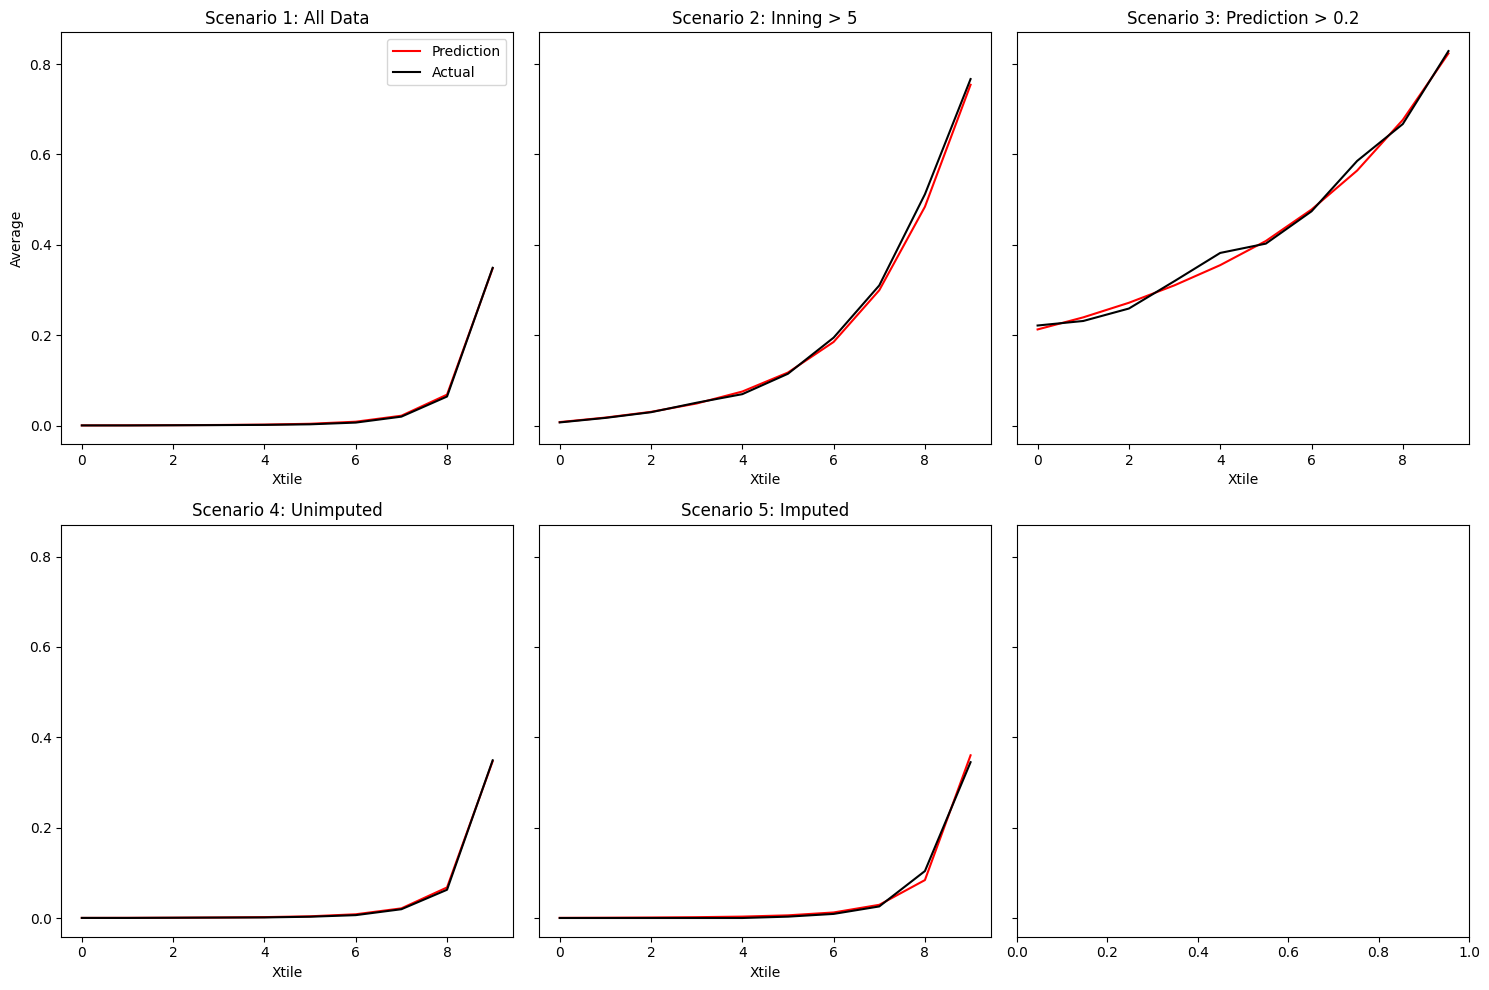

In [34]:
xtiles = 10

# First Scenario
testing_dataset['xtile1'] = pd.qcut(testing_dataset['is_pulled_pred'], xtiles, labels=False)
is_pulled_df1 = testing_dataset.groupby('xtile1')[['pulled', 'is_pulled_pred']].mean().reset_index()

# Second Scenario
testing_dataset['xtile2'] = pd.qcut(testing_dataset.query('inning > 5')['is_pulled_pred'], xtiles, labels=False)
is_pulled_df2 = testing_dataset.query('inning > 5').groupby('xtile2')[['pulled', 'is_pulled_pred']].mean().reset_index()

# Third Scenario
testing_dataset['xtile3'] = pd.qcut(testing_dataset.query('is_pulled_pred > 0.2')['is_pulled_pred'], xtiles, labels=False)
is_pulled_df3 = testing_dataset.query('is_pulled_pred > 0.2').groupby('xtile3')[['pulled', 'is_pulled_pred']].mean().reset_index()

# Unimputed
testing_dataset['xtile4'] = pd.qcut(testing_dataset.query('imp_p_adj == 0')['is_pulled_pred'], xtiles, labels=False)
is_pulled_df4 = testing_dataset.query('imp_p_adj == 0').groupby('xtile4')[['pulled', 'is_pulled_pred']].mean().reset_index()

# Imputed
testing_dataset['xtile5'] = pd.qcut(testing_dataset.query('imp_p_adj == 1')['is_pulled_pred'], xtiles, labels=False)
is_pulled_df5 = testing_dataset.query('imp_p_adj == 1').groupby('xtile5')[['pulled', 'is_pulled_pred']].mean().reset_index()

# Create a figure with 2x3 layout
fig, axes = plt.subplots(2, 3, figsize=(15, 10), sharey=True)



# Plot each graph
axes[0,0].plot(is_pulled_df1['xtile1'], is_pulled_df1['is_pulled_pred'], color='red', label='Prediction')
axes[0,0].plot(is_pulled_df1['xtile1'], is_pulled_df1['pulled'], color='black', label='Actual')
axes[0,0].set_title('Scenario 1: All Data')
axes[0,0].set_xlabel('Xtile')
axes[0,0].set_ylabel('Average')

axes[0,1].plot(is_pulled_df2['xtile2'], is_pulled_df2['is_pulled_pred'], color='red', label='Prediction')
axes[0,1].plot(is_pulled_df2['xtile2'], is_pulled_df2['pulled'], color='black', label='Actual')
axes[0,1].set_title('Scenario 2: Inning > 5')
axes[0,1].set_xlabel('Xtile')

axes[0,2].plot(is_pulled_df3['xtile3'], is_pulled_df3['is_pulled_pred'], color='red', label='Prediction')
axes[0,2].plot(is_pulled_df3['xtile3'], is_pulled_df3['pulled'], color='black', label='Actual')
axes[0,2].set_title('Scenario 3: Prediction > 0.2')
axes[0,2].set_xlabel('Xtile')

axes[1,0].plot(is_pulled_df4['xtile4'], is_pulled_df4['is_pulled_pred'], color='red', label='Prediction')
axes[1,0].plot(is_pulled_df4['xtile4'], is_pulled_df4['pulled'], color='black', label='Actual')
axes[1,0].set_title('Scenario 4: Unimputed')
axes[1,0].set_xlabel('Xtile')

axes[1,1].plot(is_pulled_df5['xtile5'], is_pulled_df5['is_pulled_pred'], color='red', label='Prediction')
axes[1,1].plot(is_pulled_df5['xtile5'], is_pulled_df5['pulled'], color='black', label='Actual')
axes[1,1].set_title('Scenario 5: Imputed')
axes[1,1].set_xlabel('Xtile')

# Add a legend to the first plot
axes[0,0].legend()

# Adjust layout for clarity
plt.tight_layout()
plt.show()

##### Late Game

In [35]:
testing_dataset.query('inning > 5').groupby('imp_p_adj')[['pulled', 'is_pulled_pred']].mean()

,pulled,is_pulled_pred
imp_p_adj,,
0,0.205817,0.200697
1,0.256959,0.250506


##### By Inning

In [36]:
(testing_dataset
    .query("inning > 0")
    .assign(inning_group=lambda df: df["inning"].sub(1).clip(lower=0))  # makes 0,1,2,...
    .groupby(["imp_p_adj", "inning_group"])[["pulled", "is_pulled_pred"]]
    .mean())

pulled  is_pulled_pred
imp_p_adj inning_group                         
0         0            0.001376        0.001647
          1            0.003750        0.004133
          2            0.008680        0.010643
          3            0.024012        0.027552
          4            0.084646        0.087659
          5            0.188312        0.180723
          6            0.251092        0.251345
          7            0.262079        0.268228
          8            0.302158        0.324216
1         0            0.002863        0.002884
          1            0.004451        0.008469
          2            0.018154        0.019247
          3            0.040302        0.049574
          4            0.132530        0.124817
          5            0.242268        0.235211
          6            0.338028        0.311007
          7            0.250000        0.455400